# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Python/Data/yulu_rental.csv')

In [3]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [4]:
# Розмір набору даних
df.shape

(10886, 19)

In [5]:
# Перегляд даних
df.head(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


**Попередній висновок по набору даних:**


*   в датафреймі міститься 10886 рядків та 19 колонок
*   в одному рядку даних міститься інформація за одну годину на конкретну дату.
З урахуванням такого набору даних аналіз може проводитися в різних варіантах проміжків часу: по годинам, датам, тижням, місяцям, рокам.



## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [6]:
# Поденна кількість орендованих велисипедів
daily_count = df.groupby('date')['count'].sum()

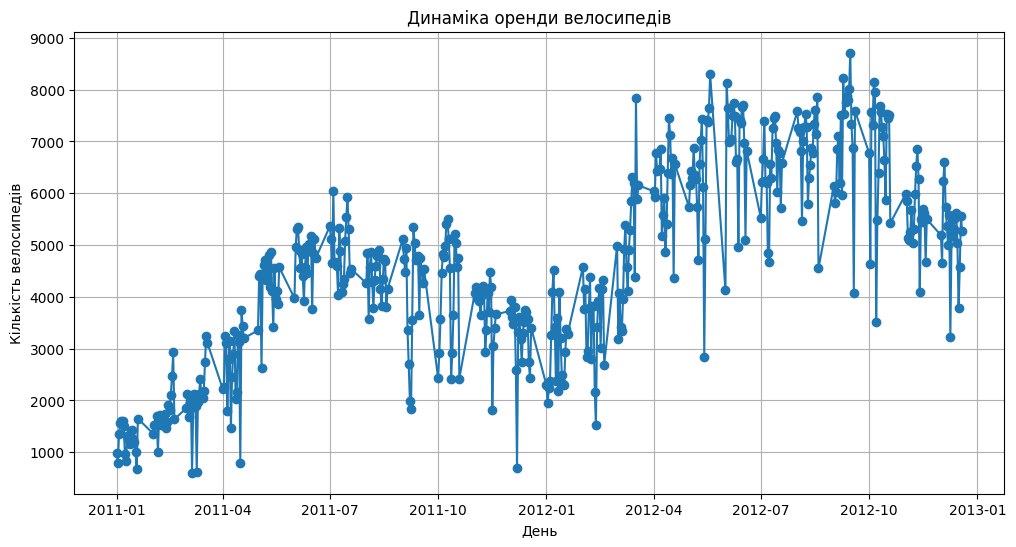

In [7]:
daily_count.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='День',
    ylabel='Кількість велосипедів',
    grid=True
);

**Відповіді на питання:**

1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли
прибрати заломи?

*Заломи спричинені деталізаціємо по дням, де могли бути погані погодні умови для оренди велисипедів та тим, що в наборі даних містяться дані Індії де сезонність відрізняється від сезонності в Європі. Аби їх прибрати краще згрупувати дані по місяцям.*

2. Які загальні тенденції ви бачите на графіку?

*Спостерігається тенденція, що починаючи з квітня оренда вилосипедів починає зростати та тримаються високі значення до жовтня. З кожним наступним роком відбувається збільшення кількості оренди велисопедів, що говорить про зростання бізнесу.*

3. Чи помітні якісь сезонні коливання?

*Так, починаючи з квітня по жовтень, коли починається теплий період, спостерігається найбільша активність оренди велосипедів.*

4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?

*Так, є такі аномалії.
Аномально низькі значення спостерігаються в грудні 2011 року та в травні 2012 року в період сезону оренди велосипедів. Це може бути пов'язано з несприятливими погодними умовами в якісь дні цих періодів.
Аномально високі значення спостерігаються в деякі дні березня 2012 року та в вересні 2012 року. Можна припустити, що в якісь дні цих періодів була дуже сприятлива погода.*


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [10]:
# Середня кількість орендованих велосипедів по кварталам
quarterly_avg_count = df.groupby('season')['count'].mean()

In [11]:
quarterly_avg_count

,count
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


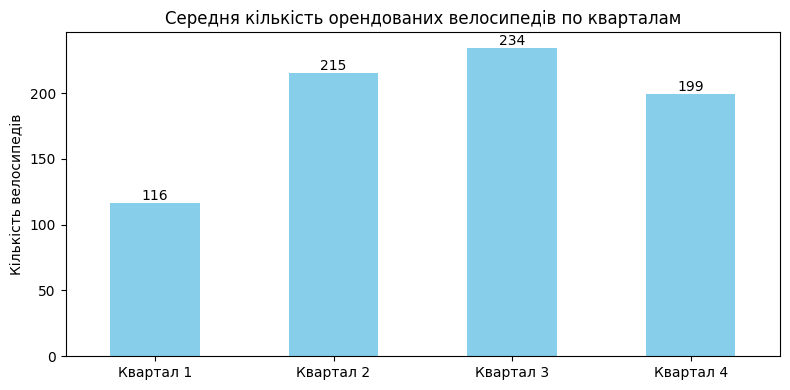

In [53]:
ax = quarterly_avg_count.plot.bar(
    figsize=(8, 4),
    color='skyblue',
    title='Середня кількість орендованих велосипедів по кварталам',
    ylabel='Кількість велосипедів',
    xlabel=''
)
plt.xticks(rotation=0)
plt.tight_layout()
ax.bar_label(ax.containers[0], fmt='%.0f')

# Налаштування підписів
ax.set_xticklabels(['Квартал 1', 'Квартал 2', 'Квартал 3', 'Квартал 4']);

**Відповіді на питання:**

1. В який квартал найбільша середня кількість оренди велосипедів?

*В третьому кварталі найбільша середня кількість оренди велосипедів.*

2. Як ви можете пояснити таку сезонну закономірність?

*В цей період відбувається покращення погодних умов, світловий день стає довшим, що і впливає на збільшення годин оренди по кожному дню в цей період.*

3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами?

*З розрахунків нижче видно, що середня оренда між першим та третім кварталами відрізняється в 2 рази*

In [13]:
max_count = quarterly_avg_count.max()
min_count = quarterly_avg_count.min()
ratio = max_count / min_count

In [14]:
# У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами
ratio

2.0148749597441986

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [15]:
# Середня кількість орендованих велосипедів по місяцях за годину
monthly_avg_count = df.groupby('month')['count'].mean()

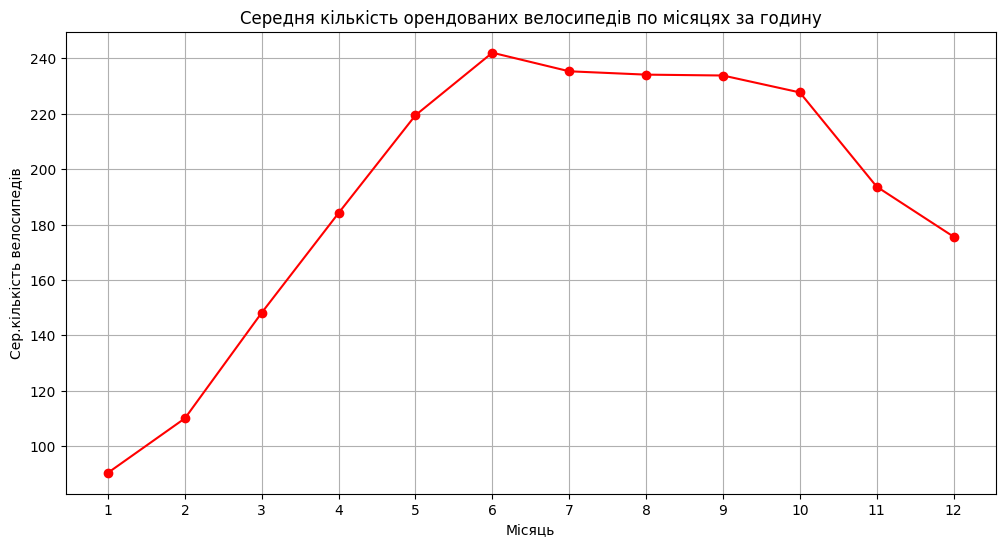

In [16]:
monthly_avg_count.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    color='red',
    title='Середня кількість орендованих велосипедів по місяцях за годину',
    xlabel='Місяць',
    ylabel='Сер.кількість велосипедів',
    grid=True
)
plt.xticks(range(1, 13))
plt.show()

**Відповіді на питання:**

1. В які місяці спостерігається пік та спад оренди?

*Пік оренди велосипедів на годину спостерігається в періоді червень-жовтень, а спад - в періоді лістопад-січень.*

2. Чи збігається ця закономірність з результатами з попереднього завдання?

*Так, зберігається. В минулому завдання пік приходився на 3 квартал, якому відповідає період червень-серпень.*

3. Як може вплинути клімат на оренду велосипедів протягом року?

*За умови сприятливих погодних умов оренда велосипедів зростає, тобто відбувається пряма залежність від температури повітря. Чим тепліше температура повітря, тим більше орендується велосипедів.*

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

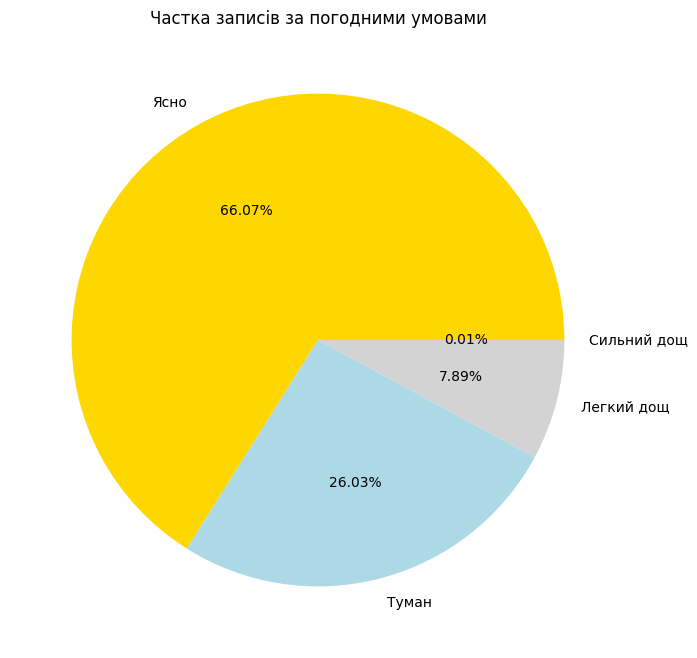

In [17]:
# Кількість записів за типами погоди
weather_count = df.groupby('weather')['day'].count()

In [22]:
weather_count

,day
weather,
1,7192
2,2834
3,859
4,1


In [18]:
weather_share = weather_count / weather_count.sum() * 100

In [19]:
weather_share

,day
weather,
1,66.066507
2,26.033437
3,7.890869
4,0.009186


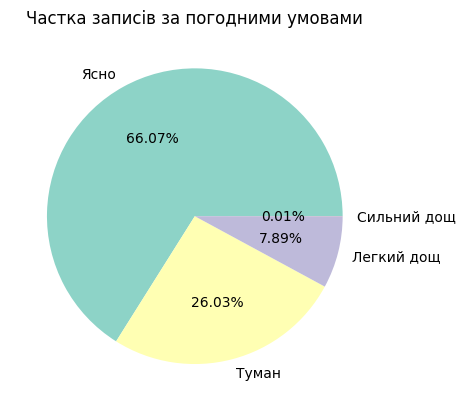

In [55]:
weather_count.plot.pie(
    # figsize=(8, 8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel='',
    colors=plt.cm.Set3.colors
);

**Відповіді на питання:**

1. Яка погода переважає в датасеті?

*В датасеті переважає погода ясно, яка складає 66,07% записів.*

2. Чи є дні із сильним дощем? Яка їх частка?

*Так, є 1 запис з сильним дощем, який складає 0,01%.*

3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

*На попит на оренду велосипедів впливають погодні умові аби не було опадів, тобто має бути ясна погода та допускається туман. На оренду велосипедів в туман припадає кожен четвертий запис.*


## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [25]:
df['weather_name'] = df['weather'].map({
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
})

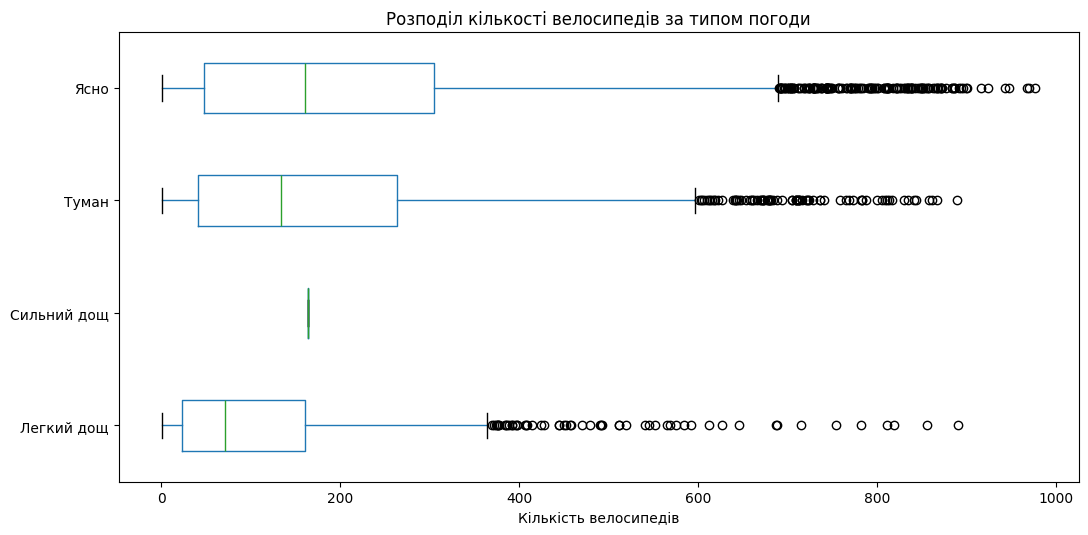

In [34]:
df.boxplot(
    column='count',
    by='weather_name',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    figsize=(12, 6),
    grid = False,
    vert=False
)
plt.title('Розподіл кількості велосипедів за типом погоди')
plt.suptitle('')
plt.ylabel('')
plt.xlabel('Кількість велосипедів')
plt.show()

**Відповіді на питання:**

1. При якій погоді найбільший розкид у кількості оренди?

*Найбільший розкид (якщо враховувати викиди) — при ясній погоді: значення розтягуються від 0 до майже 1000 велосипедів.
Якщо дивитися тільки на міжквартильний розмах (саму коробку, без викидів), то "Ясно" і "Туман" мають майже однакову ширину коробки (приблизно від 40-50 до 300-350), тобто розкид основної маси даних у них близький один до одного.*

2. Чи є викиди (outliers) в даних? При якій погоді?

*Так, викиди є в трьох типах погоди окрім сильного дощу.
Такий розподіл показав, що в спостереженні було багато днів з невеликою кількістю оренди і меншість днів з дуже великою кількістю ореди, бо була гарна погода, вихідні, святкові дні — тоді на графіку такі дні з великою кількістю оренди велосипедів потрапили в "викиди".*

3. При якій погоді медіанне значення оренди найвище?

*Візуально при ясній погоді та при сильному дощу медіани виглядають однаковими, але судячи з розрахунку нище при сильному дощу медіана вище навіть якщо було більше даних при ясній погоді.*

In [38]:
# Медіана по типам погоди
df.groupby('weather_name')['count'].median()

,count
weather_name,
Легкий дощ,71.0
Сильний дощ,164.0
Туман,134.0
Ясно,161.0


## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

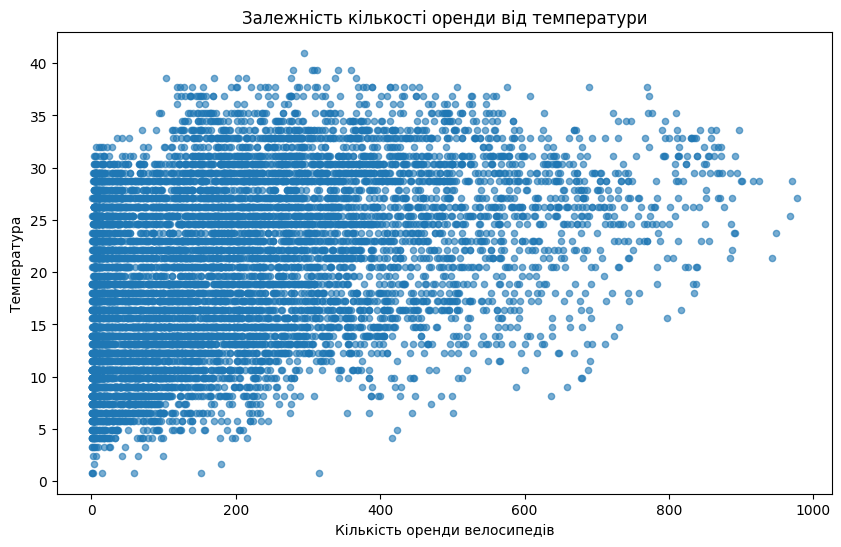

In [57]:
df.plot.scatter(
    x='count',
    y='temp',
    title='Залежність кількості оренди від температури',
    figsize=(10, 6),
    alpha=0.6
)
plt.ylabel('Температура')
plt.xlabel('Кількість оренди велосипедів')
plt.suptitle('')
plt.show()

**Чи є зв'язок між температурою та кількістю оренди? Який?**

*Так, спостерігається помірна позитивна залежність між температурою та кількістю орендованих велосипедів, але не сильна.
При низьких температурах (0-10°C) переважна більшість точок зосереджена в лівій частині графіка і кількість оренди велосипедів складає до 200-300 велосипедів.
При температурі 20-35°C зосереджена найбільша кількість точок з найбільшою кількістю оренди велосипедів.
А при температурі більше 35°C попит на оренду зменшується.*

*Можна зробити висновок, що люди частіше й активніше орендують велосипеди в теплішу, комфортну погоду (приблизно 20-35°C), і значно рідше — в холодну або спектону погоду.*

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [48]:
avg_users = df.groupby('weekday')[['casual', 'registered']].mean()

In [49]:
avg_users

,casual,registered
weekday,,
Friday,31.001962,166.842381
Monday,29.843972,160.546744
Saturday,63.625000,133.040404
Sunday,57.051298,123.788474
Thursday,24.007083,173.289118
Tuesday,22.979207,166.744639
Wednesday,22.521599,165.889749


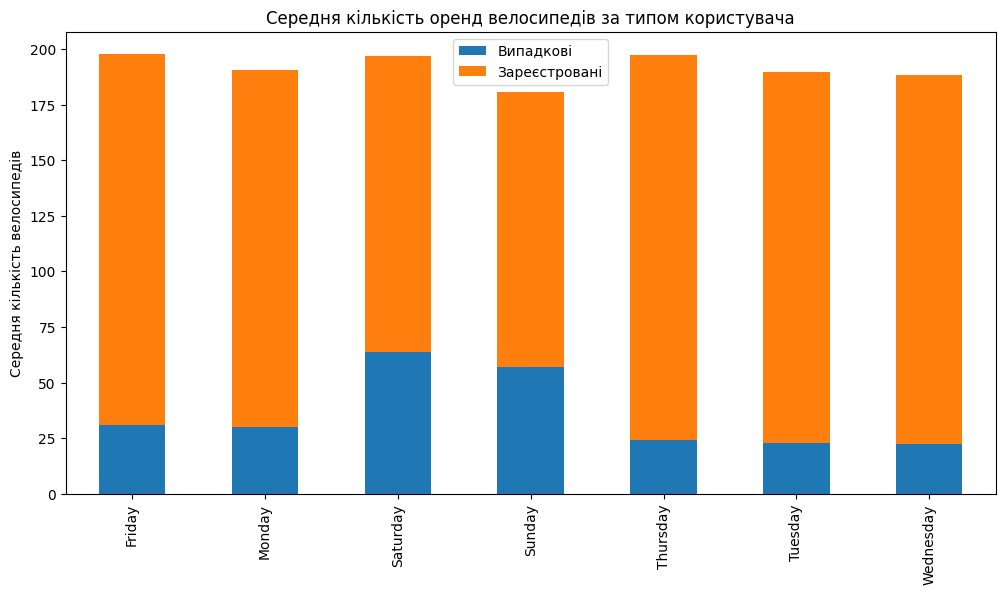

In [52]:
avg_users.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Середня кількість оренд велосипедів за типом користувача')
plt.xlabel('')
plt.ylabel('Середня кількість велосипедів')
plt.legend(['Випадкові', 'Зареєстровані'])

plt.show()

**Відповіді на питання:**

1. В які дні тижня більше оренд від зареєстрованих користувачів?

*Найбільше оренд від зареєстрованих користувачів припадає на будні дні, а у  вихідні дні кількість оренд зареєстрованими користувачами помітно нижча.
Натомість випадкові користувачі поводяться протилежно — на графіку видно, що саме в суботу і неділю частка випадкових оренд суттєво зростає порівняно з буднями.*

2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

*Це можна пояснити тим, що зареєстровані користувачі — це переважно постійні клієнти, які, ймовірно, використовують велосипеди для поїздки на роботу/ навчання. Саме тому їхня активність висока саме в будні дні, а у вихідні активність зареєстрованих користувачів падає, оскільки зникає потреба їздити на роботу/навчання.
Випадкові користувачі — це, ймовірно, туристи, гості міста або мешканці, які катаються заради відпочинку/дозвілля у вільний час, тобто у вихідні.*